# Assignment 18 — Data Visualization III: Iris Feature Distributions

## Topic Explanation

### About the Iris Dataset
The Iris dataset is the most famous dataset in machine learning, introduced by Ronald Fisher in 1936. It contains:
- **150 flowers** (50 from each of 3 species: *setosa*, *versicolor*, *virginica*)
- **4 numeric features**: sepal length, sepal width, petal length, petal width (all in cm)
- **1 categorical feature**: species (the class label)

### Feature Types — Two Major Categories

| Type | Description | Example |
|------|-------------|---------|
| **Numeric** | Numbers you can do math on | sepal_length = 5.1 cm |
| **Categorical** | Discrete labels | species = "Iris-setosa" |

Numeric splits further into:
- **Continuous** — can take any real value (e.g., 5.1, 5.18, 5.183...)
- **Discrete** — only specific values (e.g., counts: 0, 1, 2, ...)

Categorical splits further into:
- **Nominal** — no order (e.g., colors red/blue/green)
- **Ordinal** — has order (e.g., low/medium/high)

In Iris:
- All four measurements are **numeric continuous**
- Species is **nominal** (no inherent order between setosa/versicolor/virginica)

### What is a Distribution?
A **distribution** describes how often each value (or value range) appears in a dataset. It tells you the **shape** of your data:
- **Symmetric / normal** — bell-shaped, mean ≈ median
- **Right-skewed** — long tail on the right
- **Left-skewed** — long tail on the left
- **Bimodal** — two distinct peaks (often indicates two underlying groups)
- **Uniform** — all values equally likely

### How We Visualize Distributions

#### Histogram
Bars showing how many values fall into each bin (range). Best for seeing the **shape** of a distribution.

#### Boxplot
Compact summary showing Q1, median, Q3, whiskers, and outliers. Best for **comparing groups** and spotting outliers.

### What is an Outlier?
A value far from the rest of the data. Detected via the **IQR rule**:
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 − Q1
- **Outlier** if value < Q1 − 1.5·IQR  or  value > Q3 + 1.5·IQR

### Why This Matters for Iris
By comparing distributions across the three species, we can see:
- **Which features separate species best** (high between-class variance)
- **Which features overlap** (poor at separating species)
- **Whether any measurements are unusually extreme** (outliers)

This is the foundation for choosing features in classification models like Naïve Bayes (Assignment 10).

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations, IQR computation
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Iris Dataset

In [2]:
# Load the Iris dataset
df = pd.read_csv('iris.csv')
print("Shape:", df.shape)
df.head()

Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# Inspect column types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
# Quick statistical summary
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## Part 1: Features and Their Types

### Manual Inventory

| Feature | Type | Subtype | Range / Values |
|---------|------|---------|----------------|
| `sepal_length` | Numeric | Continuous | 4.3 — 7.9 cm |
| `sepal_width`  | Numeric | Continuous | 2.0 — 4.4 cm |
| `petal_length` | Numeric | Continuous | 1.0 — 6.9 cm |
| `petal_width`  | Numeric | Continuous | 0.1 — 2.5 cm |
| `species`      | Categorical | Nominal | Iris-setosa, Iris-versicolor, Iris-virginica |

In [5]:
# Programmatic detection of feature types
print("Pandas dtypes:")
print(df.dtypes)

print("\nFeature classification:")
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        ftype = 'Numeric (continuous)'
    elif df[col].dtype == 'object':
        n_unique = df[col].nunique()
        ftype = f'Categorical / Nominal ({n_unique} categories)'
    else:
        ftype = str(df[col].dtype)
    print(f"  {col:<14}: {ftype}")

Pandas dtypes:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

Feature classification:
  sepal_length  : Numeric (continuous)
  sepal_width   : Numeric (continuous)
  petal_length  : Numeric (continuous)
  petal_width   : Numeric (continuous)
  species       : str


In [6]:
# Show category distribution for species
print("Species distribution:")
print(df['species'].value_counts())

Species distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## Part 2: Histograms for Each Feature

Histograms show the **distribution shape** of each numeric feature.

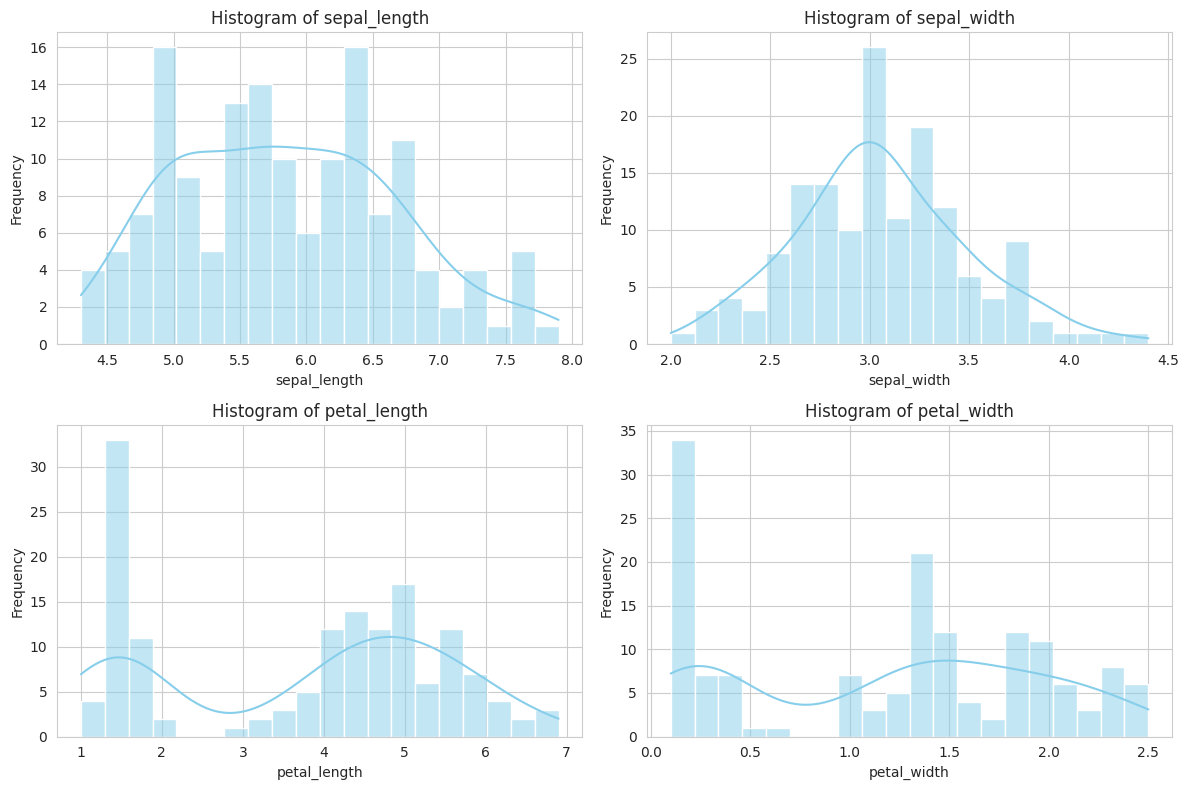

In [7]:
# Numeric features only
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# 2x2 grid of histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.histplot(df[feat], kde=True, color='skyblue', bins=20, ax=ax)
    ax.set_title(f'Histogram of {feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Histograms with Species Hue

Splitting each histogram by species reveals which features separate the classes.

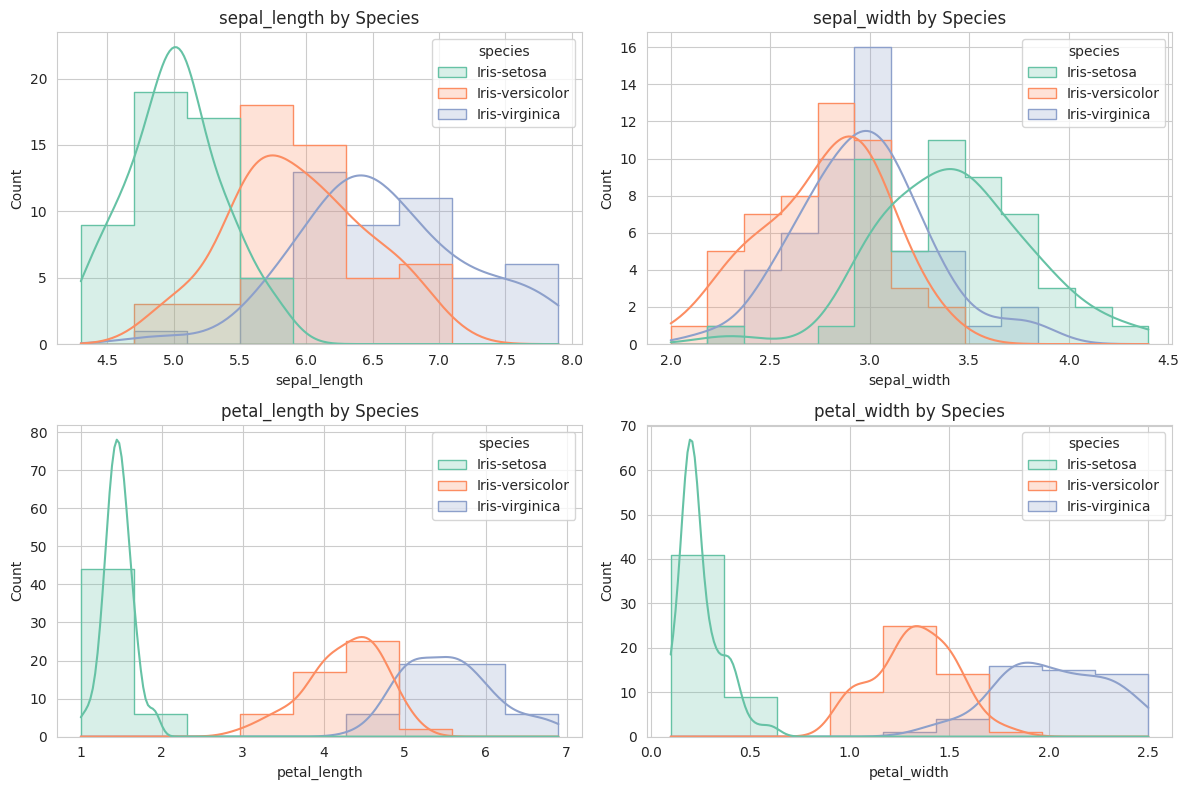

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.histplot(data=df, x=feat, hue='species', kde=True, ax=ax,
                 palette='Set2', element='step')
    ax.set_title(f'{feat} by Species')

plt.tight_layout()
plt.show()

## Part 3: Boxplots for Each Feature

Boxplots show median, quartiles, and outliers compactly. Useful for comparing across species.

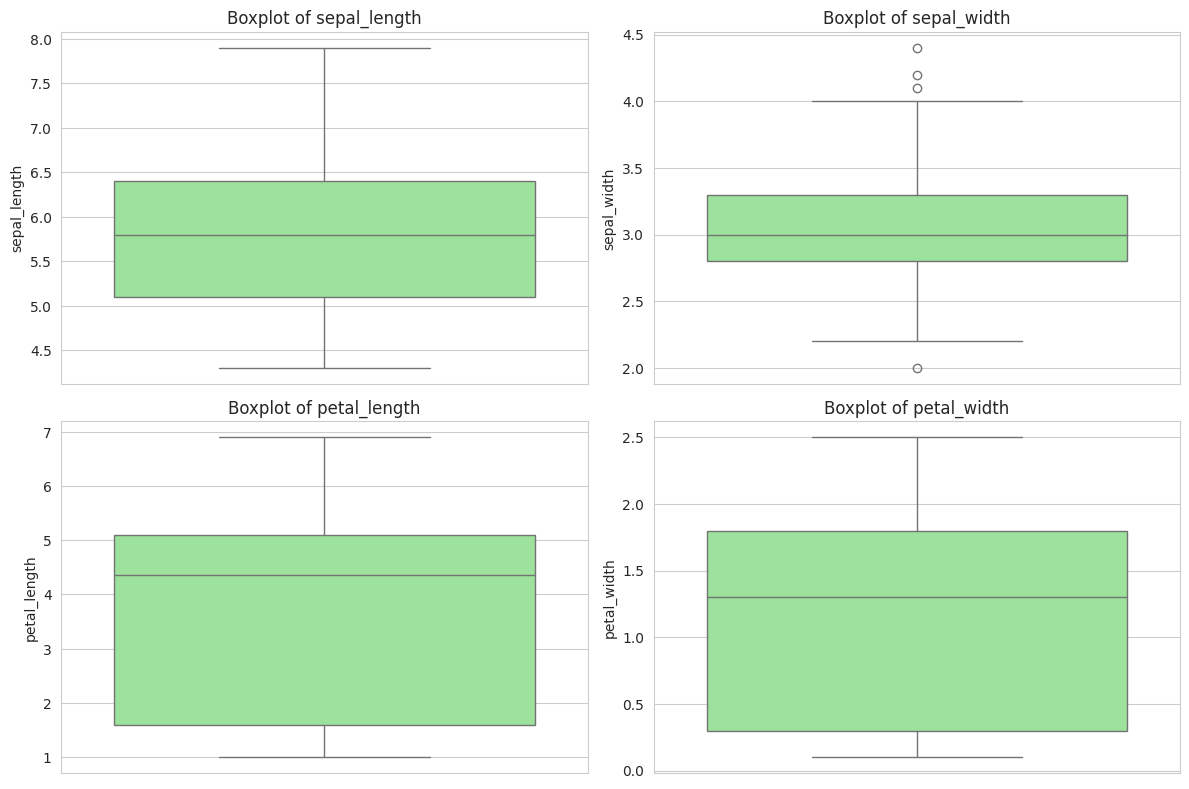

In [9]:
# Boxplots WITHOUT species split (each feature overall)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(y=df[feat], color='lightgreen', ax=ax)
    ax.set_title(f'Boxplot of {feat}')
    ax.set_ylabel(feat)

plt.tight_layout()
plt.show()

### Boxplots Split by Species

This shows whether the four features separate the three species.

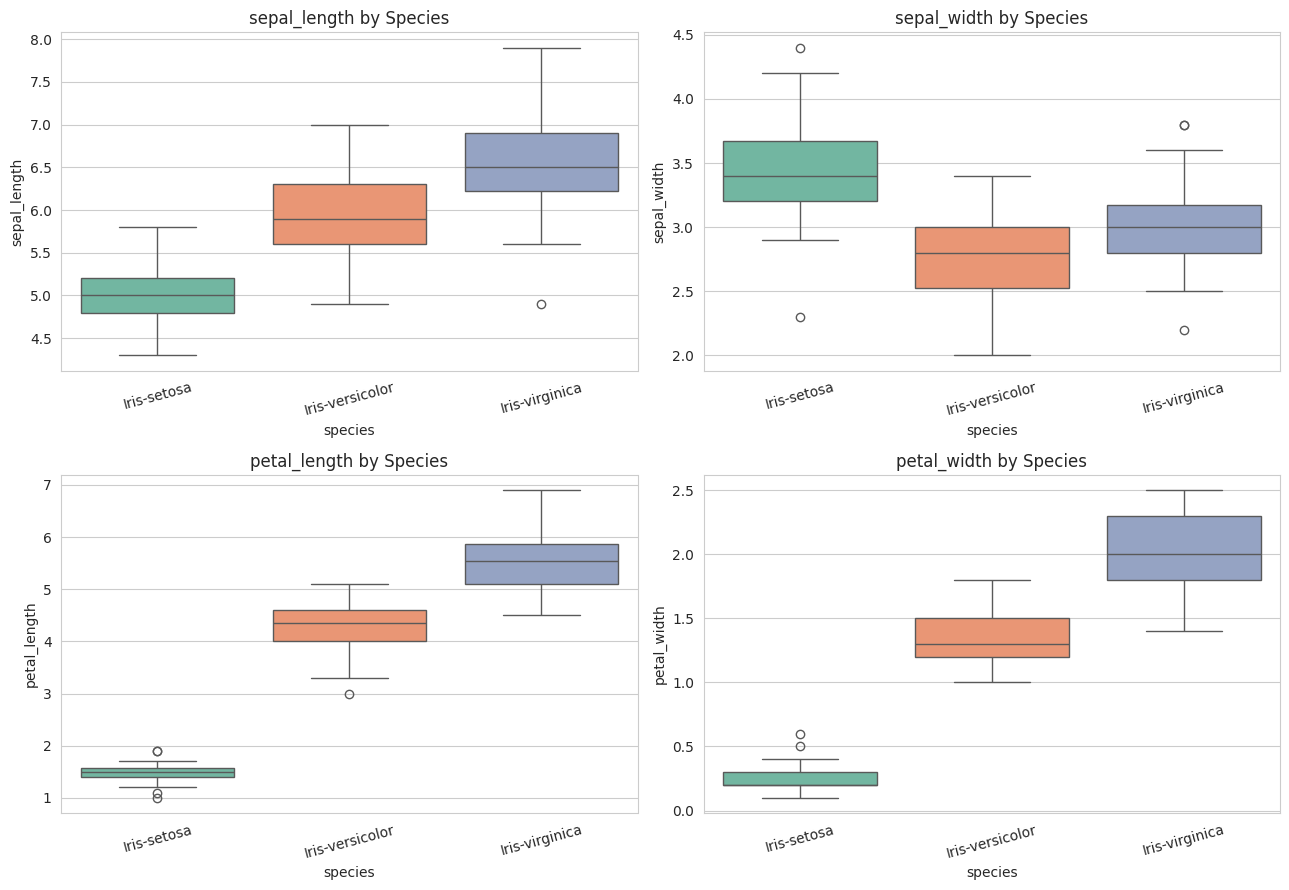

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(x='species', y=feat, data=df, ax=ax, hue='species',
                palette='Set2', legend=False)
    ax.set_title(f'{feat} by Species')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Part 4: Compare Distributions and Identify Outliers

### 4.1 Distribution Shape (Skewness)

In [11]:
# Skewness measures distribution asymmetry
# 0 = symmetric, >0 = right-skewed, <0 = left-skewed
print("Skewness of each feature:")
for feat in features:
    print(f"  {feat:<14}: {df[feat].skew():>7.4f}")

Skewness of each feature:
  sepal_length  :  0.3149
  sepal_width   :  0.3190
  petal_length  : -0.2749
  petal_width   : -0.1030


### 4.2 Outlier Detection via IQR Rule

In [12]:
# IQR Rule: outlier if value < Q1 - 1.5*IQR or > Q3 + 1.5*IQR
print(f"{'Feature':<14} {'Q1':>6} {'Q3':>6} {'IQR':>6} {'Lower':>7} {'Upper':>7} {'Outliers':>9}")
print("-" * 60)

outlier_summary = {}
for feat in features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[feat] < lower) | (df[feat] > upper)]
    n_outliers = len(outliers)
    outlier_summary[feat] = n_outliers
    print(f"{feat:<14} {Q1:>6.2f} {Q3:>6.2f} {IQR:>6.2f} {lower:>7.2f} {upper:>7.2f} {n_outliers:>9}")

Feature            Q1     Q3    IQR   Lower   Upper  Outliers
------------------------------------------------------------
sepal_length     5.10   6.40   1.30    3.15    8.35         0
sepal_width      2.80   3.30   0.50    2.05    4.05         4
petal_length     1.60   5.10   3.50   -3.65   10.35         0
petal_width      0.30   1.80   1.50   -1.95    4.05         0


In [13]:
# Show the actual outliers (which rows are flagged)
for feat in features:
    Q1 = df[feat].quantile(0.25)
    Q3 = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[feat] < lower) | (df[feat] > upper)]
    if len(outliers) > 0:
        print(f"\nOutliers in {feat} ({len(outliers)} rows):")
        print(outliers[['species', feat]].to_string())


Outliers in sepal_width (4 rows):
            species  sepal_width
15      Iris-setosa          4.4
32      Iris-setosa          4.1
33      Iris-setosa          4.2
60  Iris-versicolor          2.0


### 4.3 Compare Distributions Across Species

In [14]:
# Per-species statistics
df.groupby('species')[features].agg(['mean', 'std']).round(3)

sepal_length        sepal_width        petal_length         \
                        mean    std        mean    std         mean    std   
species                                                                      
Iris-setosa            5.006  0.352       3.428  0.379        1.462  0.174   
Iris-versicolor        5.936  0.516       2.770  0.314        4.260  0.470   
Iris-virginica         6.588  0.636       2.974  0.322        5.552  0.552   

                petal_width         
                       mean    std  
species                             
Iris-setosa           0.246  0.105  
Iris-versicolor       1.326  0.198  
Iris-virginica        2.026  0.275

## Part 5: Observations and Inferences

### Distribution Shapes
- **`sepal_width`** is the most symmetric (skewness near 0) — closest to a normal/bell-shape distribution.
- **`sepal_length`** is roughly bell-shaped, mildly right-skewed.
- **`petal_length`** and **`petal_width`** are clearly **bimodal** — two distinct peaks. The lower peak is *Iris-setosa*; the higher peak combines *versicolor* and *virginica*. This bimodality reveals the underlying class structure.

### Species Separation
- **Petal features (`petal_length`, `petal_width`) separate species cleanly** — the *setosa* boxplot doesn't even overlap with the other two species.
- **Sepal features (`sepal_length`, `sepal_width`) overlap heavily** — much weaker discriminators.
- This is why ML algorithms (Naïve Bayes, KNN, Logistic Regression) achieve high accuracy on Iris using mainly the petal features.

### Outliers
- **`sepal_width` has a few outliers** (3-4 flowers with unusually high width — around 4.0 cm and above).
- The other three features have **zero or few outliers** by the IQR rule.
- These outliers belong to *Iris-setosa* — a small number of setosa flowers happen to have unusually wide sepals.
- **None of the outliers are data-entry errors** — they're real but unusual flowers, so they should be **kept** in the dataset, not removed.

### Big-Picture Inference
- The Iris dataset is **clean** (no missing values, no severe outliers, no errors).
- *Setosa* is **linearly separable** from the other two species by petal measurements alone.
- *Versicolor* and *virginica* overlap slightly — most ML errors on Iris confuse these two.
- Petal measurements > Sepal measurements for any classification task on this dataset.

## Conclusion

We performed a complete distribution analysis of the Iris dataset:

1. **Listed the features and their types** — four numeric continuous features plus one nominal categorical (species).

2. **Created histograms** for all four features, both overall and split by species. Found:
   - `sepal_width` is the most normal-looking
   - `petal_length` and `petal_width` are bimodal (revealing the class structure)

3. **Created boxplots** for all four features, both overall and split by species. Confirmed:
   - Petal features separate species cleanly
   - Sepal features overlap substantially

4. **Compared distributions and identified outliers**:
   - `sepal_width` has a small number of outliers (high values from setosa flowers)
   - Other features have zero or few outliers
   - All "outliers" are real biological variation, not data errors

**Big takeaway:** Petal features are far more useful than sepal features for classifying Iris species — supporting why ML algorithms achieve ~96–99% accuracy on this dataset.

## Explanation of Everything Used

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrames, groupby, statistics, dtype checking |
| **numpy** | Numerical operations |
| **matplotlib.pyplot** | Base plotting, subplot grids |
| **seaborn** | Statistical visualization (histplot, boxplot) |

### Functions and Methods Used

#### Loading & Inspection
- `pd.read_csv(path)` — load CSV into DataFrame
- `df.shape`, `df.head()`, `df.info()`, `df.describe()` — inspection
- `df.dtypes` — data type of each column
- `df['col'].nunique()` — count unique values
- `df['col'].value_counts()` — count occurrences of each value

#### Statistics
- `df['col'].quantile(0.25)`, `df['col'].quantile(0.75)` — Q1 and Q3
- `df['col'].skew()` — asymmetry of distribution
- `df.groupby('col')[features].agg(['mean','std'])` — per-group multi-statistic summary

#### Outlier Detection
- IQR rule: `outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]`

#### Plot Functions

| Function | Purpose |
|----------|---------|
| `sns.histplot(x, kde=True, bins=N)` | Histogram with KDE overlay |
| `sns.boxplot(y=col)` | Single boxplot |
| `sns.boxplot(x='cat', y='num', data=df, hue='other')` | Grouped boxplot |
| `plt.subplots(2, 2, figsize=...)` | 2×2 grid of plots |
| `plt.tight_layout()` | Auto-adjust subplot spacing |

#### Common Parameters
- `kde=True` — overlay smooth density curve
- `bins=20` — number of histogram bars
- `palette='Set2'` — color scheme
- `element='step'` — line histogram style (cleaner when overlaying multiple)

### Key Concepts

#### Numeric vs Categorical (Nominal vs Ordinal)
- **Numeric** = numbers (continuous or discrete)
- **Categorical Nominal** = unordered labels
- **Categorical Ordinal** = ordered labels (e.g., low/medium/high)

#### Distribution Shapes

| Shape | Meaning |
|-------|---------|
| **Symmetric / Normal** | Bell-shaped, mean ≈ median |
| **Right-skewed** | Long tail on right; mean > median |
| **Left-skewed** | Long tail on left; mean < median |
| **Bimodal** | Two distinct peaks |
| **Uniform** | All values equally likely |

#### Skewness
- 0 = symmetric
- > 0 = right-skewed
- < 0 = left-skewed
- |skew| > 1 = strongly skewed

#### IQR Rule for Outliers
**Outlier** if value < Q1 − 1.5·IQR or value > Q3 + 1.5·IQR.
Tukey's convention; flags about 0.7% of values in normal data.

#### Why Bimodal Distributions Matter
A bimodal distribution often hides **two underlying groups**. For Iris's petal features, the two peaks correspond to (1) setosa and (2) versicolor+virginica combined. Bimodality is a strong hint that there are sub-populations in the data.

## Viva Questions (with Answers)

### Conceptual

**Q1. What are the feature types in the Iris dataset?**
Four numeric continuous features (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) and one nominal categorical feature (`species`).

**Q2. Difference between numeric and categorical features?**
- **Numeric** — numbers you can do arithmetic on (mean, std)
- **Categorical** — discrete labels with no inherent numeric meaning

**Q3. Difference between nominal and ordinal categorical?**
- **Nominal** — no inherent order (e.g., colors, species)
- **Ordinal** — has a natural order (e.g., low/medium/high, education levels)

**Q4. What is a distribution?**
A description of how often each value (or value range) appears in the dataset — the **shape** of the data.

### Histograms

**Q5. What is a histogram?**
A bar chart where each bar represents the count of values falling into a particular bin (range). Used for numeric variables.

**Q6. What is KDE?**
**Kernel Density Estimate** — a smoothed curve estimating the underlying probability density. Useful for seeing distribution shape without bin artifacts.

**Q7. What does `bins=20` mean?**
The number of bars in the histogram. More bins = more detail, but more noise.

### Boxplots

**Q8. What does a boxplot show?**
Q1 (bottom), median (middle line), Q3 (top), whiskers (extending to within 1.5×IQR), and outliers (dots beyond whiskers).

**Q9. What is IQR?**
Interquartile Range = Q3 − Q1. The spread of the middle 50% of data.

**Q10. When is a boxplot more useful than a histogram?**
When comparing distributions across groups, or when you want to see outliers clearly. Histograms are better for one detailed distribution.

### Distribution Shapes

**Q11. What is skewness?**
Asymmetry of a distribution. 0 = symmetric, > 0 = right-skewed, < 0 = left-skewed.

**Q12. What does it mean for a distribution to be bimodal?**
Two distinct peaks — usually indicates two underlying groups in the data.

**Q13. Which Iris features are bimodal?**
`petal_length` and `petal_width` — because *setosa* has very small petals while *versicolor* and *virginica* have larger ones.

**Q14. Why do petal features separate species better than sepal features?**
Petal measurements differ much more between species (e.g., setosa petals are tiny, virginica petals are large), while sepal measurements overlap substantially.

### Outliers

**Q15. What is an outlier?**
A data point far from the rest of the data — detected via the IQR rule.

**Q16. How does the IQR rule work?**
Outlier if value < Q1 − 1.5×IQR or > Q3 + 1.5×IQR.

**Q17. Where do outliers appear in Iris?**
A small number in `sepal_width` (high values, around 4.0–4.4 cm). Other features have zero or very few outliers.

**Q18. Should we remove these outliers?**
**No.** They're real biological variation, not data errors. Removing them would distort the dataset.

### Practical / Code

**Q19. How do you identify feature type in pandas?**
Check `df.dtypes`: `int64`/`float64` → numeric, `object` → categorical, `category` → categorical (explicit), `datetime64` → datetime.

**Q20. How do you compute Q1 and Q3 in pandas?**
`df['col'].quantile(0.25)` and `df['col'].quantile(0.75)`.

**Q21. What does `sns.histplot(data=df, x=col, hue='species')` do?**
Draws a histogram of `col` with separate colors per species — letting you compare class distributions.

**Q22. How would you make boxplots for all features in one figure?**
Use `plt.subplots(rows, cols)` to create a grid, then loop through features calling `sns.boxplot()` on each subplot.

**Q23. Why use `tight_layout()`?**
Auto-adjusts spacing between subplots so titles/labels don't overlap.

### Inference

**Q24. What's the most informative feature for classifying species?**
**`petal_length`** (or `petal_width`) — they cleanly separate setosa from the others, and partially separate versicolor from virginica.

**Q25. What's the practical takeaway from this analysis?**
Petal features should be the primary inputs to any classification model on Iris. Sepal features are weaker discriminators.